# Normalizing flows with vectorized micrograd: eight Gaussians

A small, tweakable notebook for comparing additive coupling and affine coupling on a toy 2-D dataset using vectorized micrograd.

Run the notebook top-to-bottom to see dataset plots, invertibility checks, NLL curves, generated samples, and a learned log-density grid.


In [1]:
from pathlib import Path
import sys

# Make imports work whether the notebook is in the repo root or in examples/.
CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent]

for root in candidates:
    if (root / "vect_micrograd").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        PROJECT_ROOT = root
        break
else:
    raise RuntimeError(
        "Could not find the vect_micrograd package. "
        "Open this notebook from the project root or move it into the project."
    )

print("Project root:", PROJECT_ROOT)

Project root: /home/r00t/Downloads/Karpathy/vect_micrograd_flows


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from vect_micrograd.flows import make_flow
from vect_micrograd.optim import Adam, RMSProp
from vect_micrograd.utils import (
    clip_grad_norm,
    full_nll,
    init_flow_near_identity,
    load_state,
    save_state,
)

np.set_printoptions(precision=4, suppress=True)


## 1. Tweakable configuration

Start here. The defaults are conservative and should be stable. Eight Gaussians is a harder stress test for additive coupling than two moons, so increase `steps`, `hidden_sizes`, or `num_coupling_layers` gradually.

In [3]:
# Dataset
n_data = 4096
radius = 2.0
gaussian_noise = 0.08
standardize_data = True
seed = 0

# Model
hidden_sizes = (64, 64)
num_coupling_layers = 10
prior = "normal"       # "normal" or "logistic"
flow_kind = "realnvp"  # "nice" for additive coupling, "realnvp" for affine coupling

# Training
steps = 40000
batch_size = 512       # set to n_data for full-batch training
learning_rate = 5e-4
log_every = 200
eval_every = 200

# Stabilizers
use_grad_clip = True
max_grad_norm = 5.0
restore_best_model = True

## 2. Eight-Gaussians dataset

This dataset places eight small Gaussian clusters around a ring. It is a useful stress test because the distribution is multimodal with low-density gaps between modes.

In [4]:
def make_eight_gaussians(n, radius=2.0, noise=0.08, seed=0, standardize=True, dtype=np.float32):
    rng = np.random.default_rng(seed)

    angles = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
    centers = np.stack([np.cos(angles), np.sin(angles)], axis=1) * radius

    labels = rng.integers(0, len(centers), size=n)
    X = centers[labels] + noise * rng.standard_normal((n, 2))

    if standardize:
        X = (X - X.mean(axis=0, keepdims=True)) / X.std(axis=0, keepdims=True)

    return X.astype(dtype, copy=False), labels.astype(np.int64, copy=False)


X, labels = make_eight_gaussians(
    n_data,
    radius=radius,
    noise=gaussian_noise,
    seed=seed,
    standardize=standardize_data,
)

print("X shape:", X.shape)
print("mean:", X.mean(axis=0))
print("std:", X.std(axis=0))

X shape: (4096, 2)
mean: [-0. -0.]
std: [1. 1.]


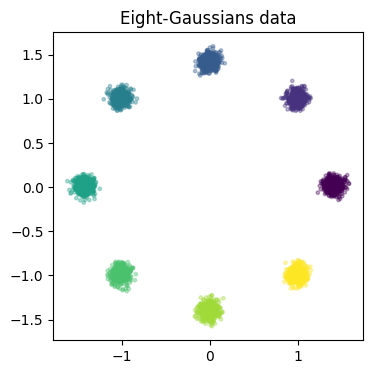

In [5]:
plt.figure(figsize=(4.5, 4.0))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=6, alpha=0.35)
plt.title("Eight-Gaussians data")
plt.gca().set_aspect("equal")
plt.show()

## 3. Build the flow model

In [6]:
flow_kwargs = {}
if flow_kind in {"realnvp", "affine"}:
    flow_kwargs["max_log_scale"] = 2.0

model = make_flow(
    kind=flow_kind,
    dim=2,
    hidden_sizes=hidden_sizes,
    num_coupling_layers=num_coupling_layers,
    prior=prior,
    **flow_kwargs,
)

init_flow_near_identity(model)
print(model)


RealNVPFlow(dim=2, layers=10, prior=StandardNormal(dim=2))


## 4. Sanity check: invertibility

In [7]:
z, logdet = model.forward(X[:10])
x_roundtrip = model.inverse(z).data
max_abs_error = np.max(np.abs(x_roundtrip - X[:10]))

print("z shape:", z.data.shape)
print("logdet shape:", logdet.data.shape)
print("logdet:", logdet.data)
print("max |inverse(forward(x)) - x|:", max_abs_error)

z shape: (10, 2)
logdet shape: (10,)
logdet: [ 0.0309 -0.0069 -0.0389  0.0861  0.0864  0.2016  0.2268  0.2114  0.2432
  0.0318]
max |inverse(forward(x)) - x|: 3.5762787e-07


## 5. Train

In [8]:
loss_history = []
full_loss_history = []
grad_norm_history = []

params = list(model.parameters())
optimizer = Adam(params, lr=learning_rate, weight_decay=0.0)

best_full_nll = float("inf")
best_state = None
best_step = None

rng = np.random.default_rng(seed + 1)

for step in range(steps):
    if batch_size >= len(X):
        xb = X
    else:
        idx = rng.integers(0, len(X), size=batch_size)
        xb = X[idx]

    optimizer.zero_grad()
    loss = model.nll(xb)
    loss.backward()

    if use_grad_clip:
        grad_norm = clip_grad_norm(params, max_norm=max_grad_norm)
    else:
        grad_norm = np.nan

    optimizer.step(step)

    loss_value = loss.item()
    loss_history.append(loss_value)
    grad_norm_history.append(grad_norm)

    if step % eval_every == 0 or step == steps - 1:
        current_full_nll = full_nll(model, X)
        full_loss_history.append((step, current_full_nll))

        if current_full_nll < best_full_nll:
            best_full_nll = current_full_nll
            best_state = save_state(model)
            best_step = step

        if step % log_every == 0 or step == steps - 1:
            print(
                f"step {step:5d} | "
                f"batch nll {loss_value:.4f} | "
                f"full nll {current_full_nll:.4f} | "
                f"best {best_full_nll:.4f} at step {best_step} | "
                f"grad_norm {grad_norm:.2f}"
            )

if restore_best_model and best_state is not None:
    load_state(model, best_state)
    print(f"restored best model from step {best_step}, full nll={best_full_nll:.4f}")

step     0 | batch nll 2.8188 | full nll 2.7858 | best 2.7858 at step 0 | grad_norm 11.42
step   200 | batch nll 1.2944 | full nll 1.3354 | best 1.3354 at step 200 | grad_norm 112.20
step   400 | batch nll 1.2570 | full nll 1.1794 | best 1.1794 at step 400 | grad_norm 129.57
step   600 | batch nll 0.5684 | full nll 0.8495 | best 0.8495 at step 600 | grad_norm 131.23
step   800 | batch nll 0.5199 | full nll 0.4944 | best 0.4944 at step 800 | grad_norm 433.86
step  1000 | batch nll 0.2742 | full nll 0.1849 | best 0.1849 at step 1000 | grad_norm 233.35
step  1200 | batch nll 0.2627 | full nll 0.2587 | best 0.1849 at step 1000 | grad_norm 259.24
step  1400 | batch nll 0.1928 | full nll 0.0543 | best 0.0543 at step 1400 | grad_norm 235.31
step  1600 | batch nll -0.0038 | full nll -0.0869 | best -0.0869 at step 1600 | grad_norm 141.85
step  1800 | batch nll -0.0443 | full nll -0.0262 | best -0.0869 at step 1600 | grad_norm 405.81
step  2000 | batch nll -0.2114 | full nll -0.0925 | best -0.09

## 7. Plot training curves

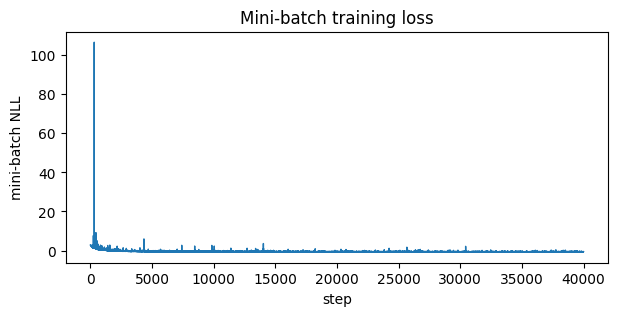

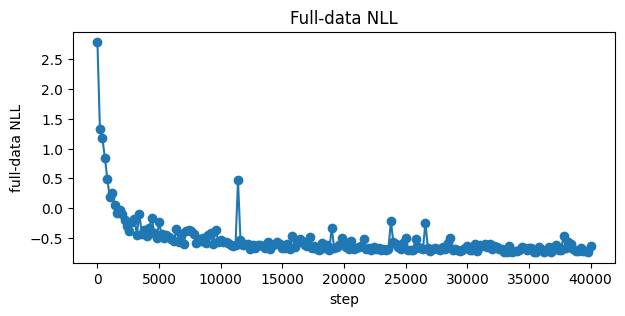

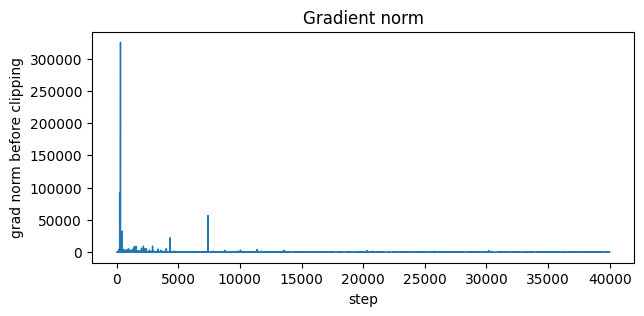

In [9]:
plt.figure(figsize=(7, 3))
plt.plot(loss_history, linewidth=1)
plt.xlabel("step")
plt.ylabel("mini-batch NLL")
plt.title("Mini-batch training loss")
plt.show()

if full_loss_history:
    steps_eval, full_vals = zip(*full_loss_history)
    plt.figure(figsize=(7, 3))
    plt.plot(steps_eval, full_vals, marker="o")
    plt.xlabel("step")
    plt.ylabel("full-data NLL")
    plt.title("Full-data NLL")
    plt.show()

if use_grad_clip:
    plt.figure(figsize=(7, 3))
    plt.plot(grad_norm_history, linewidth=1)
    plt.xlabel("step")
    plt.ylabel("grad norm before clipping")
    plt.title("Gradient norm")
    plt.show()

## 8. Samples

For eight Gaussians, additive coupling often learns the ring structure before it learns sharp separated blobs. This plot is the most direct visual check of the sampler.

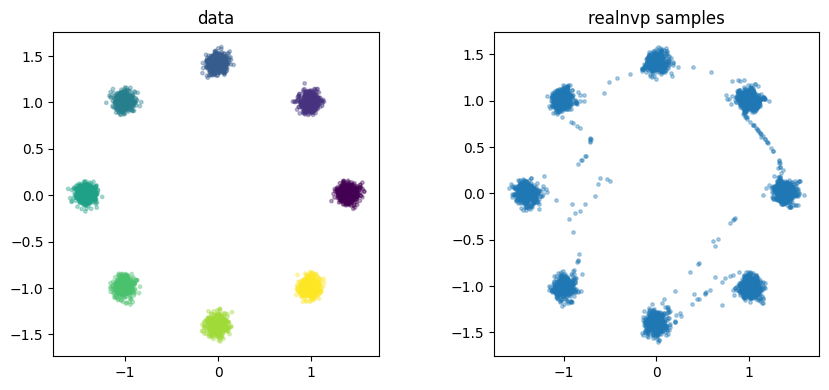

In [10]:
samples = model.sample(len(X))

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=6, alpha=0.35)
plt.title("data")
plt.gca().set_aspect("equal")

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.35)
plt.title(f"{flow_kind} samples")
plt.gca().set_aspect("equal")

plt.tight_layout()
plt.show()

## 9. Learned log-density

The raw log-density can have a huge dynamic range. The plot below shows relative log-density, `log p(x) - max log p(x)`, clipped to `[-20, 0]`, which is much more informative for flow visualizations.

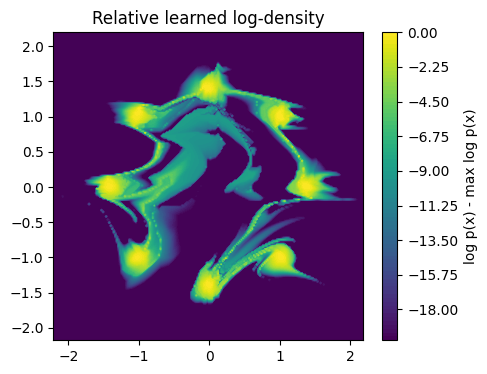

In [11]:
grid_size = 200

x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

xs = np.linspace(x_min, x_max, grid_size)
ys = np.linspace(y_min, y_max, grid_size)

xx, yy = np.meshgrid(xs, ys)
grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(X.dtype)

logp = model.log_prob(grid).data.reshape(grid_size, grid_size)

logp_rel = logp - np.max(logp)
logp_rel_clipped = np.clip(logp_rel, -20.0, 0.0)

plt.figure(figsize=(5, 4))
plt.contourf(
    xx,
    yy,
    logp_rel_clipped,
    levels=np.linspace(-20, 0, 81),
)
# plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.15)
plt.title("Relative learned log-density")
plt.gca().set_aspect("equal")
plt.colorbar(label="log p(x) - max log p(x)")
plt.show()